In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import shap
import xgboost as xgb

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, f1_score, make_scorer

In [2]:
# Load the pre-processed datasets
df_prehension = pd.read_csv("../../data/02_processed/prehension_master_dataset.csv")
df_aiming = pd.read_csv("../../data/02_processed/aiming_master_dataset.csv")
df_illusions = pd.read_csv("../../data/02_processed/visual_illusions_master_dataset.csv")

In [3]:
def get_curated_features(df, drop_cols=[]):
    leaky_patterns = ['Xmax', 'Ymax', 'Zmax', 'FX', 'FY', 'FZ', 'Xloc', 'Yloc', 'Zloc']
    identifiers = ['subjName', 'trialN']
    
    kinematic_features = df.select_dtypes(include=np.number).columns.tolist()
    kinematic_features = [col for col in kinematic_features if col not in identifiers and col not in drop_cols]
    
    curated_features = [
        feat for feat in kinematic_features
        if not any(pattern in feat for pattern in leaky_patterns)
    ]
    return curated_features

# Get curated features for each dataset
features_prehension = get_curated_features(df_prehension)
features_aiming = get_curated_features(df_aiming)
features_illusions = get_curated_features(df_illusions, drop_cols=['targetSize'])

print("Setup complete. Datasets and feature lists are ready.")


Setup complete. Datasets and feature lists are ready.


# Benchmarking Models (Random Forest vs. XGBoost)

In [ ]:
# Prepare data
X = df_illusions[features_illusions]
y = df_illusions['illusion']
groups = df_illusions['subjName']

# Encode target labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
label_map = {i: label for i, label in enumerate(le.classes_)}
print(f"Label mapping for Illusions: {label_map}")

Label mapping for Illusions: {0: 'Ebbinghaus', 1: 'Ponzo'}


In [ ]:
# Define pipelines for each model
pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

pipeline_xgb = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', xgb.XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss'))
])


In [ ]:
# Setup cross-validation
group_kfold = GroupKFold(n_splits=5)
f1_scorer = make_scorer(f1_score, average='weighted')


In [ ]:
# Run CV for both models
print("\nRunning Cross-Validation for Random Forest...")
cv_scores_rf = cross_val_score(pipeline_rf, X, y_encoded, cv=group_kfold, groups=groups, scoring=f1_scorer)
print(f"Random Forest Weighted F1 Scores: {cv_scores_rf}")
print(f"Mean F1 Score: {np.mean(cv_scores_rf):.4f} (+/- {np.std(cv_scores_rf):.4f})")

print("\nRunning Cross-Validation for XGBoost...")
cv_scores_xgb = cross_val_score(pipeline_xgb, X, y_encoded, cv=group_kfold, groups=groups, scoring=f1_scorer)
print(f"XGBoost Weighted F1 Scores: {cv_scores_xgb}")
print(f"Mean F1 Score: {np.mean(cv_scores_xgb):.4f} (+/- {np.std(cv_scores_xgb):.4f})")

print("\nFitting XGBoost on the full dataset for SHAP analysis...")
pipeline_xgb.fit(X, y_encoded)



Running Cross-Validation for Random Forest...
Random Forest Weighted F1 Scores: [0.76649791 0.64750373 0.70621218 0.75262631 0.65262889]
Mean F1 Score: 0.7051 (+/- 0.0492)

Running Cross-Validation for XGBoost...
XGBoost Weighted F1 Scores: [0.76217421 0.62638308 0.67074557 0.76985879 0.66433763]
Mean F1 Score: 0.6987 (+/- 0.0571)

Fitting XGBoost on the full dataset for SHAP analysis...


,steps,"[('scaler', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None


# SHAP Analysis

In [ ]:
scaler = pipeline_xgb.named_steps['scaler']
model = pipeline_xgb.named_steps['classifier']

# Scale the data first, as the model was trained on scaled data
X_scaled = scaler.transform(X)

# 1. Create the SHAP Explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_scaled)



Generating SHAP Summary Plot...


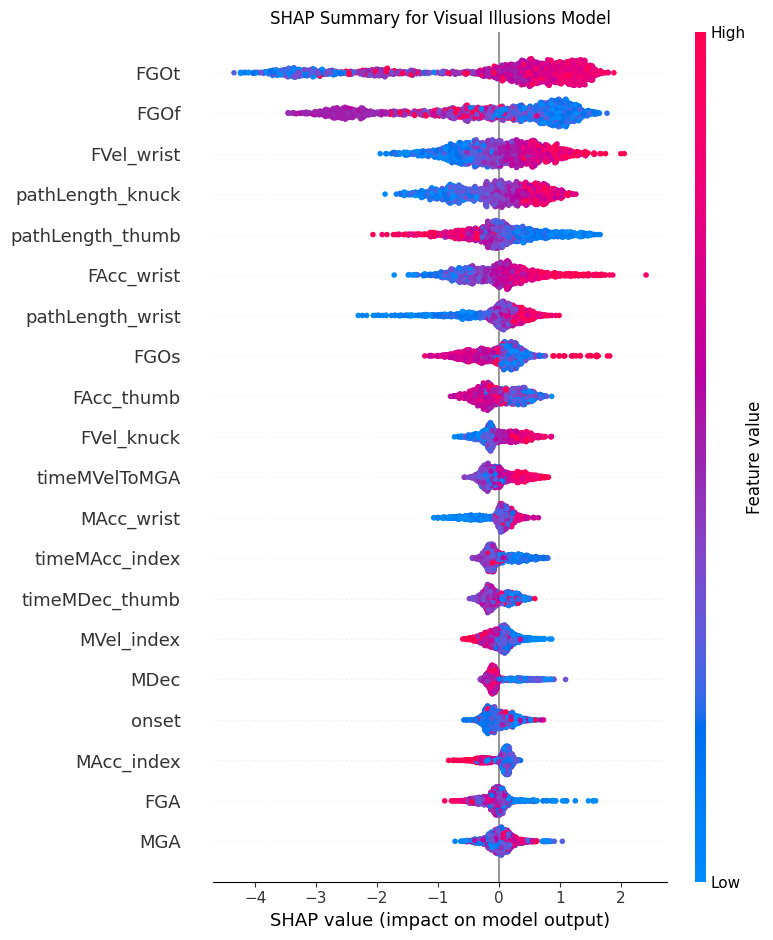

In [ ]:
# 2. SHAP Summary Plot (Beeswarm)
print("\nGenerating SHAP Summary Plot...")
plt.title("SHAP Summary for Visual Illusions Model")
shap.summary_plot(shap_values, X, class_names=le.classes_, show=False)
plt.savefig("../../results/figures/illusions_shap_summary.png", bbox_inches='tight')
plt.show()


SHAP values type: <class 'numpy.ndarray'>
SHAP values shape: (1608, 74)
Shape of X: (1608, 74)
Number of classes in model: 2
Classes: ['Ebbinghaus' 'Ponzo']

Number of classes: 2
Binary classification detected - SHAP values shape should be (n_samples, n_features)

Generating SHAP Dependence Plot for 'FGOt'...


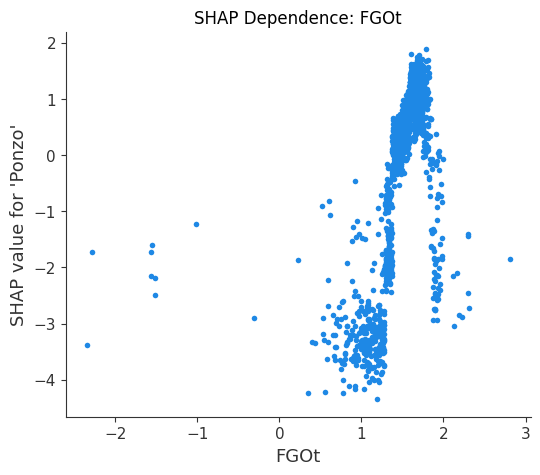


Generating SHAP Dependence Plot for 'FGOf'...


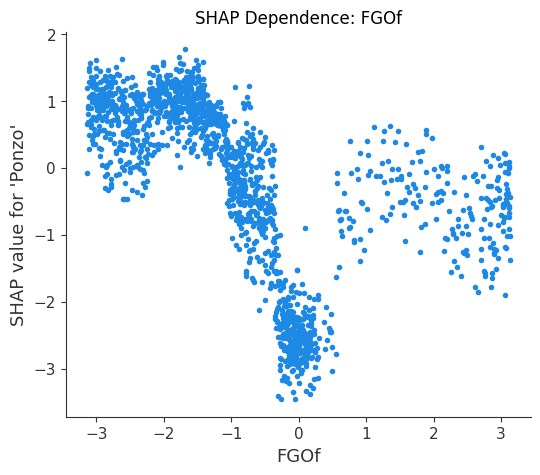


Generating SHAP Waterfall Plot for first prediction...


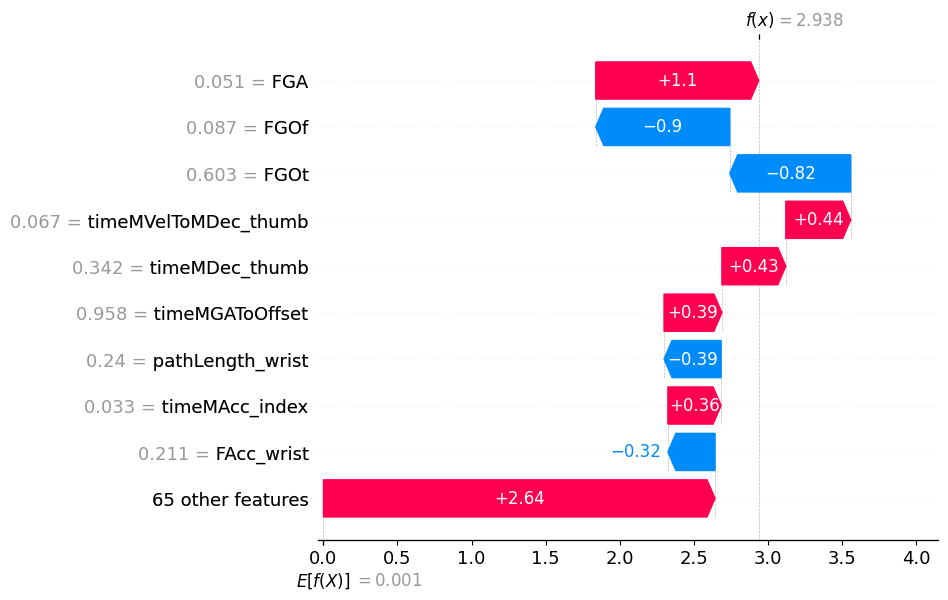


Generating SHAP Force Plot for first prediction...


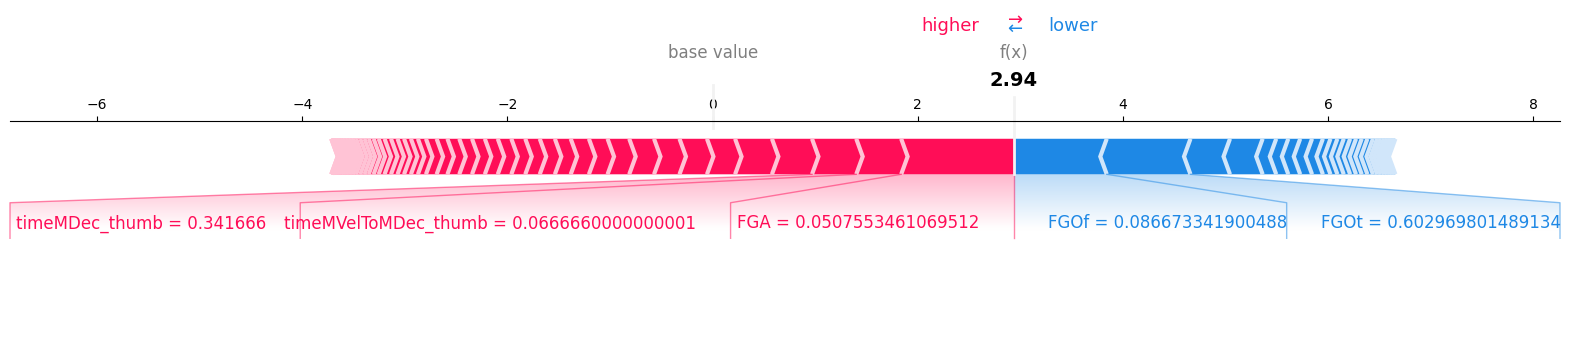

In [ ]:
print(f"SHAP values type: {type(shap_values)}")
print(f"SHAP values shape: {shap_values.shape}")
print(f"Shape of X: {X.shape}")
print(f"Number of classes in model: {len(le.classes_)}")
print(f"Classes: {le.classes_}")

top_feature_1 = 'FGOt'
top_feature_2 = 'FGOf'


n_classes = len(le.classes_)
print(f"\nNumber of classes: {n_classes}")

if n_classes == 2:
    print("Binary classification detected - SHAP values shape should be (n_samples, n_features)")
    
    print(f"\nGenerating SHAP Dependence Plot for '{top_feature_1}'...")
    shap.dependence_plot(top_feature_1, shap_values, X, interaction_index=None, show=False)
    plt.ylabel(f"SHAP value for '{le.classes_[1]}'")
    plt.title(f"SHAP Dependence: {top_feature_1}")
    plt.savefig(f"../../results/figures/illusions_shap_dependence_{top_feature_1}.png", bbox_inches='tight')
    plt.show()

    print(f"\nGenerating SHAP Dependence Plot for '{top_feature_2}'...")
    shap.dependence_plot(top_feature_2, shap_values, X, interaction_index=None, show=False)
    plt.ylabel(f"SHAP value for '{le.classes_[1]}'")
    plt.title(f"SHAP Dependence: {top_feature_2}")
    plt.savefig(f"../../results/figures/illusions_shap_dependence_{top_feature_2}.png", bbox_inches='tight')
    plt.show()
    
else:
    print("Multi-class classification detected")
    if isinstance(shap_values, list):
        print("SHAP values is a list - using class-specific values")
        shap.dependence_plot(top_feature_1, shap_values[1], X, interaction_index=None, show=False)
        plt.ylabel("SHAP value for 'Ponzo'")
        plt.savefig(f"../../results/figures/illusions_shap_dependence_{top_feature_1}.png", bbox_inches='tight')
        plt.show()
    
    elif len(shap_values.shape) == 3:
        print("SHAP values is 3D array - using class-specific values")
        shap.dependence_plot(top_feature_1, shap_values[:, :, 1], X, interaction_index=None, show=False)
        plt.ylabel("SHAP value for 'Ponzo'")
        plt.savefig(f"../../results/figures/illusions_shap_dependence_{top_feature_1}.png", bbox_inches='tight')
        plt.show()
    
    else:
        print("Unexpected SHAP values structure. Let's try a different approach.")
        print("Re-computing SHAP values...")
        
        if hasattr(model, 'predict_proba'):
            print("Model has predict_proba - this is multi-class")
            sample_size = min(100, X.shape[0])
            sample_indices = np.random.choice(X.shape[0], sample_size, replace=False)
            X_sample = X_scaled[sample_indices]
            
            explainer_new = shap.TreeExplainer(model)
            shap_values_new = explainer_new.shap_values(X_sample)
            
            print(f"New SHAP values type: {type(shap_values_new)}")
            if isinstance(shap_values_new, list):
                print(f"Number of classes in new SHAP: {len(shap_values_new)}")
                print(f"Shape of each class: {[sv.shape for sv in shap_values_new]}")
                
                # Now plot with the sample data
                X_sample_orig = X.iloc[sample_indices]
                shap.dependence_plot(top_feature_1, shap_values_new[1], X_sample_orig, 
                                   interaction_index=None, show=False)
                plt.ylabel("SHAP value for 'Ponzo'")
                plt.title(f"SHAP Dependence: {top_feature_1} (sample)")
                plt.savefig(f"../../results/figures/illusions_shap_dependence_{top_feature_1}_sample.png", bbox_inches='tight')
                plt.show()
            else:
                print(f"New SHAP values shape: {shap_values_new.shape}")

print(f"\nGenerating SHAP Waterfall Plot for first prediction...")
if isinstance(shap_values, np.ndarray) and len(shap_values.shape) == 2:
    explanation = shap.Explanation(values=shap_values[0], 
                                 base_values=explainer.expected_value, 
                                 data=X.iloc[0].values,
                                 feature_names=X.columns.tolist())
    shap.waterfall_plot(explanation, show=False)
    plt.savefig("../../results/figures/illusions_shap_waterfall_sample.png", bbox_inches='tight')
    plt.show()
elif isinstance(shap_values, list):
    explanation = shap.Explanation(values=shap_values[1][0], 
                                 base_values=explainer.expected_value[1], 
                                 data=X.iloc[0].values,
                                 feature_names=X.columns.tolist())
    shap.waterfall_plot(explanation, show=False)
    plt.savefig("../../results/figures/illusions_shap_waterfall_sample.png", bbox_inches='tight')
    plt.show()

print(f"\nGenerating SHAP Force Plot for first prediction...")
try:
    if isinstance(shap_values, np.ndarray) and len(shap_values.shape) == 2:
        shap.force_plot(explainer.expected_value, shap_values[0], X.iloc[0], 
                       feature_names=X.columns, matplotlib=True, show=False)
        plt.savefig("../../results/figures/illusions_shap_force_sample.png", bbox_inches='tight')
        plt.show()
    elif isinstance(shap_values, list):
        shap.force_plot(explainer.expected_value[1], shap_values[1][0], X.iloc[0], 
                       feature_names=X.columns, matplotlib=True, show=False)
        plt.savefig("../../results/figures/illusions_shap_force_sample.png", bbox_inches='tight')
        plt.show()
except Exception as e:
    print(f"Force plot failed: {e}")
    print("This is normal - force plots sometimes have compatibility issues in some environments.")


Generating SHAP Force Plot for the first trial...
Expected value type: <class 'numpy.float32'>
Expected value: 0.0006639249622821808
SHAP values shape: (1608, 74)
Number of classes: 2


Binary classification - using correct indexing...


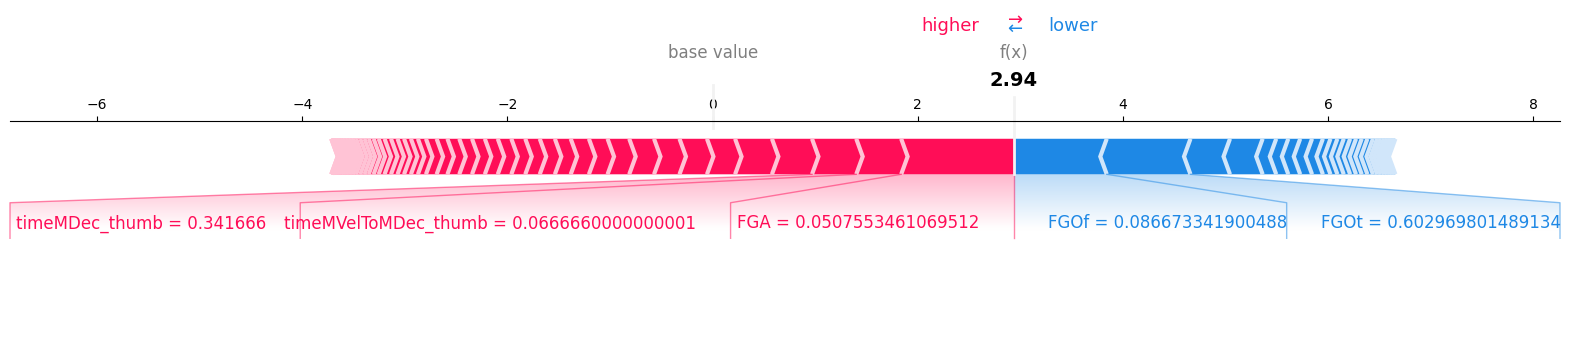

✓ Force plot saved successfully!

Generating force plots for additional interesting samples...
Most confident Ponzo prediction: sample 179 (prob: 1.000)
Most confident Ebbinghaus prediction: sample 52 (prob: 0.000)


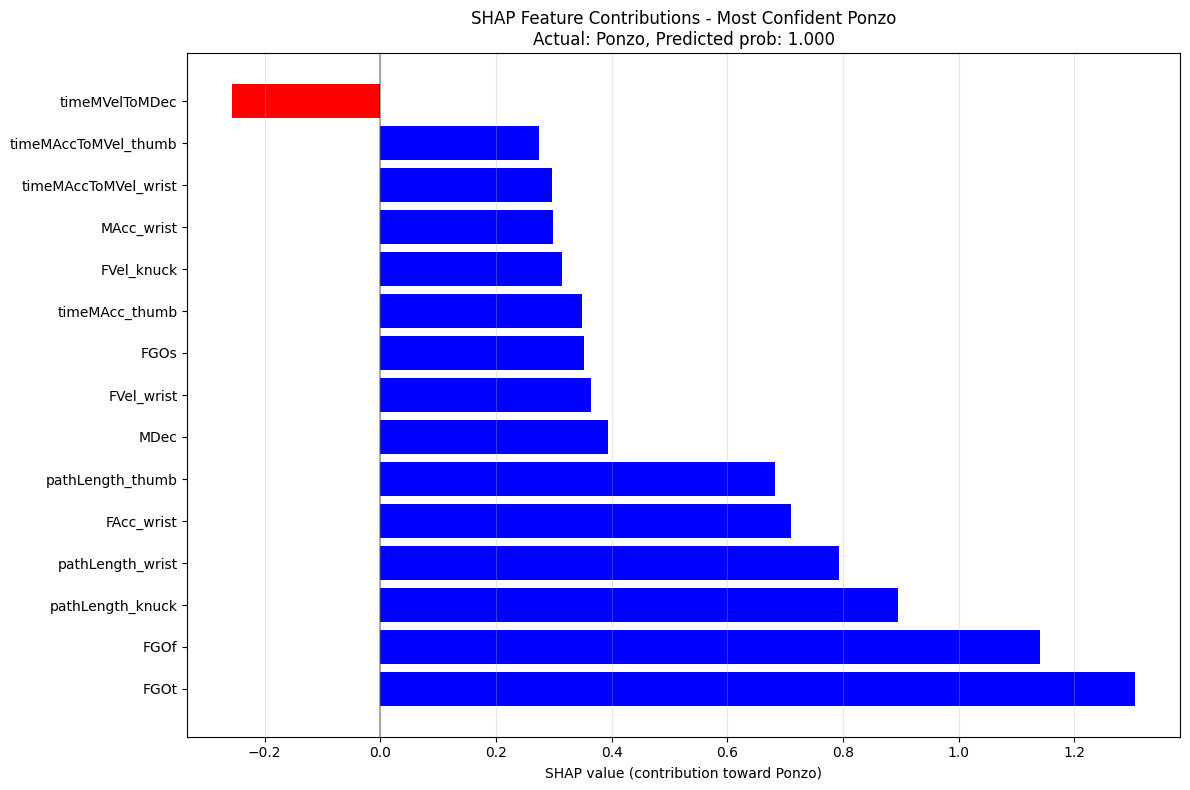

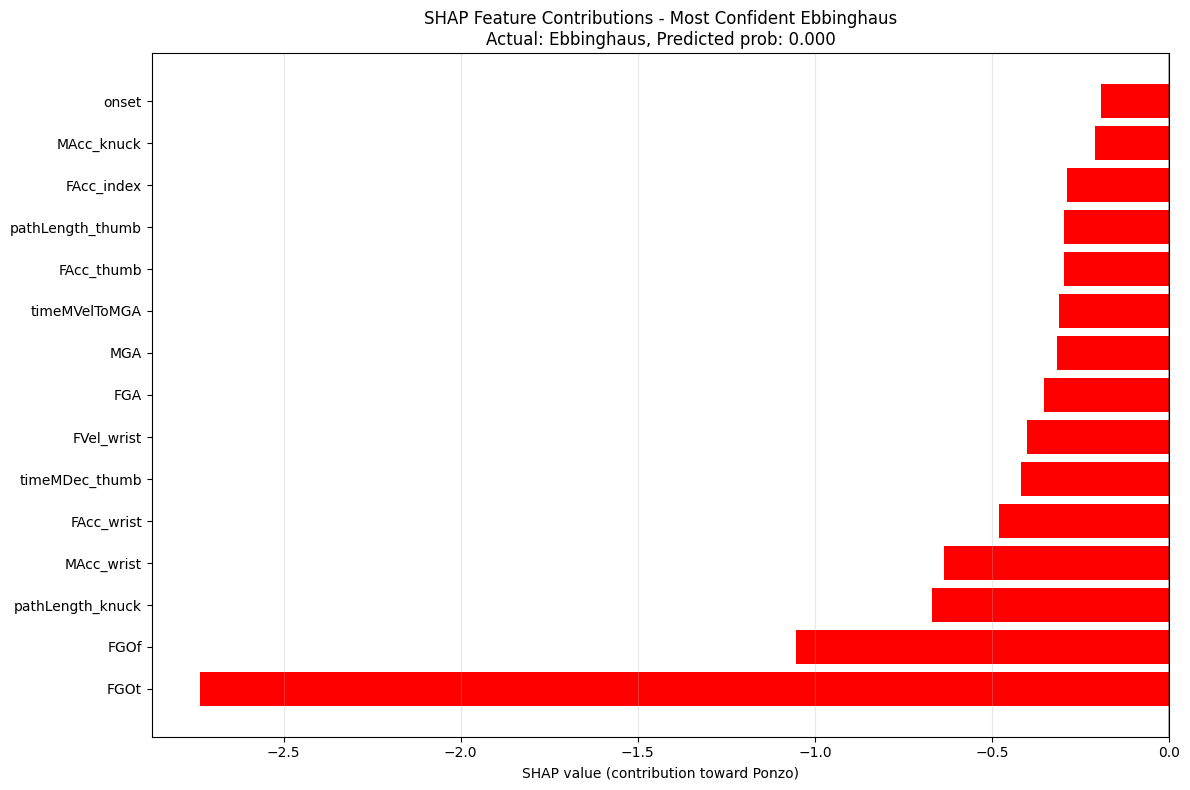

✓ Additional SHAP plots saved successfully!


In [ ]:
# 4. Individual Force Plot (Explaining a single prediction)
print("\nGenerating SHAP Force Plot for the first trial...")

# Check the structure again to be sure
print(f"Expected value type: {type(explainer.expected_value)}")
print(f"Expected value: {explainer.expected_value}")
print(f"SHAP values shape: {shap_values.shape}")
print(f"Number of classes: {len(le.classes_)}")

shap.initjs()

n_classes = len(le.classes_)

if n_classes == 2:
    print("Binary classification - using correct indexing...")
    
    try:
        shap.force_plot(explainer.expected_value,      # Scalar value (no indexing)
                       shap_values[0],                 # First sample (shape: n_features)
                       X.iloc[0],                      # First sample features
                       feature_names=X.columns,        # Feature names
                       matplotlib=True, 
                       show=False)
        plt.savefig("../../results/figures/illusions_shap_force_plot_trial0.png", 
                   bbox_inches='tight', dpi=300)
        plt.show()
        print("✓ Force plot saved successfully!")
        
    except Exception as e:
        print(f"Method 1 failed: {e}")
        
        print("Trying alternative method...")
        try:
            explanation = shap.Explanation(values=shap_values[0], 
                                         base_values=explainer.expected_value, 
                                         data=X.iloc[0].values,
                                         feature_names=X.columns.tolist())
            
            shap.waterfall_plot(explanation, show=False)
            plt.savefig("../../results/figures/illusions_shap_waterfall_trial0.png", 
                       bbox_inches='tight', dpi=300)
            plt.show()
            print("✓ Waterfall plot saved as alternative!")
            
        except Exception as e2:
            print(f"Method 2 also failed: {e2}")
            print("Let's try a simpler bar plot...")
            
            plt.figure(figsize=(12, 8))
            feature_importance = pd.Series(shap_values[0], index=X.columns)
            feature_importance_sorted = feature_importance.reindex(
                feature_importance.abs().sort_values(ascending=False).index
            )
            
            # Plot top 15 features
            top_features = feature_importance_sorted.head(15)
            colors = ['red' if x < 0 else 'blue' for x in top_features.values]
            
            plt.barh(range(len(top_features)), top_features.values, color=colors)
            plt.yticks(range(len(top_features)), top_features.index)
            plt.xlabel(f'SHAP value (contribution toward {le.classes_[1]})')
            plt.title('SHAP Feature Contributions for First Trial')
            plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
            plt.grid(axis='x', alpha=0.3)
            plt.tight_layout()
            plt.savefig("../../results/figures/illusions_shap_bar_trial0.png", 
                       bbox_inches='tight', dpi=300)
            plt.show()
            print("✓ Bar plot saved successfully!")

else:
    print("Multi-class classification detected...")
    try:
        shap.force_plot(explainer.expected_value[1], 
                       shap_values[1][0,:], 
                       X.iloc[0,:], 
                       matplotlib=True, 
                       show=False)
        plt.savefig("../../results/figures/illusions_shap_force_plot_trial0.png", 
                   bbox_inches='tight', dpi=300)
        plt.show()
    except Exception as e:
        print(f"Multi-class force plot failed: {e}")

print("\nGenerating force plots for additional interesting samples...")

# Find samples with highest and lowest predictions
if n_classes == 2:
    # Get model predictions
    y_pred_proba = pipeline_xgb.predict_proba(X)[:, 1]  # Probability of positive class
    
    # Find most confident predictions for each class
    most_confident_ponzo = np.argmax(y_pred_proba)
    most_confident_ebbinghaus = np.argmin(y_pred_proba)
    
    print(f"Most confident Ponzo prediction: sample {most_confident_ponzo} (prob: {y_pred_proba[most_confident_ponzo]:.3f})")
    print(f"Most confident Ebbinghaus prediction: sample {most_confident_ebbinghaus} (prob: {y_pred_proba[most_confident_ebbinghaus]:.3f})")
    
    # Create bar plots for these interesting cases
    for idx, label in [(most_confident_ponzo, "most_confident_ponzo"), 
                       (most_confident_ebbinghaus, "most_confident_ebbinghaus")]:
        
        plt.figure(figsize=(12, 8))
        feature_importance = pd.Series(shap_values[idx], index=X.columns)
        feature_importance_sorted = feature_importance.reindex(
            feature_importance.abs().sort_values(ascending=False).index
        )
        
        # Plot top 15 features
        top_features = feature_importance_sorted.head(15)
        colors = ['red' if x < 0 else 'blue' for x in top_features.values]
        
        plt.barh(range(len(top_features)), top_features.values, color=colors)
        plt.yticks(range(len(top_features)), top_features.index)
        plt.xlabel(f'SHAP value (contribution toward {le.classes_[1]})')
        plt.title(f'SHAP Feature Contributions - {label.replace("_", " ").title()}\n'
                 f'Actual: {y.iloc[idx]}, Predicted prob: {y_pred_proba[idx]:.3f}')
        plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
        plt.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        plt.savefig(f"../../results/figures/illusions_shap_bar_{label}.png", 
                   bbox_inches='tight', dpi=300)
        plt.show()
        
    print("✓ Additional SHAP plots saved successfully!")